# Globe3D Demo: Image Colored & Split Globe

This notebook demonstrates how to color a globe using an equirectangular image, hollow it, and split it for 3D printing.

In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import trimesh
from globe3d import (
    generate_sphere_points_fibonacci,
    load_netcdf_grid,
    calculate_displacement_scale,
    displace_vertices,
    assign_vertex_colors_image,
    resize_globe,
    combine_subtractive_globes,
    split_mesh_hemispheres,
    write_obj_with_vertex_colors
)

## 1. Generate Dummy Image

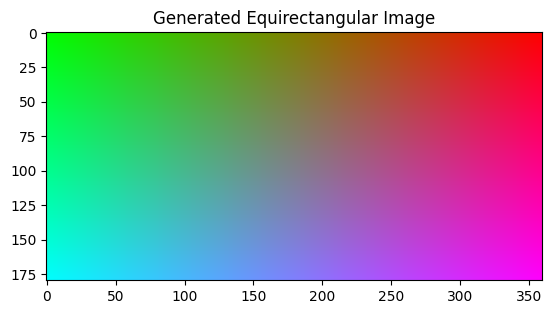

In [2]:
# Create a simple gradient image for demonstration
width, height = 360, 180
image = np.zeros((height, width, 3), dtype=np.float32)

# Horizontal gradient (Hue-like)
for x in range(width):
    image[:, x, 0] = x / width      # Red channel
    image[:, x, 1] = 1 - x / width  # Green channel

# Vertical gradient
for y in range(height):
    image[y, :, 2] = y / height     # Blue channel

plt.imsave('demo_texture.png', image)
plt.imshow(image)
plt.title("Generated Equirectangular Image")
plt.show()

## 2. Generate & Displace Sphere

In [3]:
n_points = 50000
earth_radius_km = 6371.
model_radius_mm = 40.0
    vertices, faces = generate_sphere_points_fibonacci(n_points, model_radius_mm)

# Load Grid (using dummy if not found)
topogrid = r"F:\no_backup\gmt_grids\ETOPO_2022_v1_60s_N90W180_surface.nc"
try:
    lats, lons, grid = load_netcdf_grid(topogrid, lat_var='lat', lon_var='lon', data_var='z')
except FileNotFoundError:
    print("Grid file not found. Using dummy data.")
    lats = np.linspace(-90, 90, 180)
    lons = np.linspace(-180, 180, 360)
    grid = np.zeros((180, 360))
    grid[45, 90] = 5000

# Displace
vert_exagg = 50
    scale = calculate_displacement_scale(model_radius_mm, earth_radius_km, vertical_exagg=vert_exagg)
vertices = displace_vertices(vertices, lats, lons, grid, scale, show_progress=True)

Displacing vertices:   0%|          | 0/5 [00:00<?, ?it/s]

Displacing vertices: 100%|██████████| 5/5 [00:00<00:00, 582.98it/s]

## 3. Color from Image

In [4]:
colors = assign_vertex_colors_image(vertices, 'demo_texture.png', show_progress=True)

Assigning image colors:   0%|          | 0/5 [00:00<?, ?it/s]

Assigning image colors: 100%|██████████| 5/5 [00:00<00:00, 1998.24it/s]

## 4. Hollow & Split

In [5]:
inner_vertices = resize_globe(vertices, 0.9)
combined_vertices, combined_faces, combined_colors = combine_subtractive_globes(
    vertices, faces, inner_vertices, faces, outer_colors=colors, inner_colors=colors
)

# Create Trimesh object
mesh = trimesh.Trimesh(vertices=combined_vertices, faces=combined_faces, vertex_colors=(combined_colors * 255).astype(np.uint8))

if not mesh.is_watertight:
    print("Repairing mesh...")
    mesh = trimesh.repair.fix_fill(mesh)

print("Splitting mesh...")
top_half, bottom_half = split_mesh_hemispheres(mesh)

if top_half and bottom_half:
    # Export Top Half using custom writer
    # Trimesh colors are RGBA uint8, convert to RGB float [0,1]
    top_colors = assign_vertex_colors_image(top_half.vertices, 'demo_texture.png')
    write_obj_with_vertex_colors('globe_image_top.obj', top_half.vertices, top_half.faces, top_colors)
    
    # Export Bottom Half using custom writer
    bottom_colors = assign_vertex_colors_image(bottom_half.vertices, 'demo_texture.png')
    write_obj_with_vertex_colors('globe_image_bottom.obj', bottom_half.vertices, bottom_half.faces, bottom_colors)
    
    print("Saved globe_image_top.obj and globe_image_bottom.obj")
else:
    print("Splitting failed.")

Splitting mesh...


Saved globe_image_top.obj and globe_image_bottom.obj
